### Predicting HDB Prices with Multivariate Linear Regression

Having collected the data, wrangled it together, done exploratory data analysis, we will now begin to model the data to predict HDB prices. 

In this notebook, we will be using Multivariate Linear Regression for prediction. This is a 'quick and dirty' model which is fast and reliable, with easy interpretation of model coefficients. 

The final selling price of a HDB isn’t just based on one thing - how big the HDB is, but also factors like the number of bedrooms, the age of the HDB, and maybe even how close it is to the city center. Basically all the data which we have wrangled together. Multivariate linear regression is a fancy way of saying we use all these different bits of information - size, bedrooms, age, location - to make a good guess at the HDB price. Each factor has its own weight in the equation, kind of like ingredients in a recipe, each contributing differently to the final price. 

#### **Objective:** Predict HDB Price (dependent variable) using multiple independent variables (collected data).
- **Equation for Multivariate Linear Regression**
  - Y = β₀ + β₁X₁ + β₂X₂ + ... + βₖXₖ + ε
    - Y: Dependent variable (HDB Price)
    - β₀: Y-intercept
    - β₁, β₂, ... , βₖ: Coefficients for independent variables X₁, X₂, ..., Xₖ (the weights)
    - ε: Error term
- **Assumption**
  - Assumes a linear relationship between dependent and independent variables. Involves multiple independent variables (β).
  - Assumes independence of errors, constant variance of errors (homoscedasticity), and normally distributed errors.
- **Parameters**
  - Coefficients (β) are estimated to minimize the sum of squared residuals. This is the loss function, used to create the line of best fit. 
- **Goodness of Fit**: Measured by metrics like R-squared, Mean Squared Error (MSE), Mean Absolute Error (MAE)
  - In this notebook we will use R2 and MAE.
- **Interpretation**
  - Coefficients indicate the impact/weight of each independent variable on the dependent variable.
- **Variants**
  - Multiple variations exist, including ridge and lasso regression for regularization, which will be explored in other notebooks.
  - Link for Notebook with Ridge regression:
  - Link for Notebook with Lasso regression:



#### Load Libraries

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Train Test Split
from sklearn.model_selection import train_test_split, cross_validate

# Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

# Modelling
from sklearn.linear_model import LinearRegression

# Model Evaluation
from sklearn.metrics import mean_absolute_error, r2_score
import scipy.stats as stats

# Saving Model
import pickle

import os

#### Load data into DataFrame and Remove Unwanted Columns

In [4]:
# Navigate to your project
os.chdir('/workspaces/DSE3101-Project')

# Verify you're in the right place
print("Current directory:", os.getcwd())
print("Contents:", os.listdir('.'))

# Navigate to data/raw folder
os.chdir('data/raw')

Current directory: /workspaces/DSE3101-Project
Contents: ['docs', '.git', 'notebooks', '.DS_Store', 'models', 'frontend', 'requirements.txt', '.gitignore', '.vscode', 'backend', 'requirements_fixed.txt', 'Final Web Scraper.ipynb', 'data', 'onemap_all_themes_full.json', 'README.md', 'onemap_all_themes_raw.txt']


In [7]:
hdb_df = pd.read_csv('HDB_full_resale_info.csv.gz')
print(hdb_df.info())

# Put all columns to be deleted into a list
drop_cols = ['block', 'street_name','address','sold_year_month']

# Drop columns
hdb_df = hdb_df.drop(columns=drop_cols, errors='ignore')

<class 'pandas.DataFrame'>
RangeIndex: 259143 entries, 0 to 259142
Data columns (total 37 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   town                               259143 non-null  str    
 1   flat_type                          259143 non-null  str    
 2   block                              259143 non-null  str    
 3   street_name                        259143 non-null  str    
 4   storey_range                       259143 non-null  str    
 5   floor_area_sqm                     259143 non-null  float64
 6   flat_model                         259143 non-null  str    
 7   lease_commence_date                259143 non-null  int64  
 8   resale_price                       259143 non-null  float64
 9   remaining_lease                    259143 non-null  int64  
 10  sold_year                          259143 non-null  int64  
 11  address                            259143 non-null

#### Prepare Data for Pipeline and Train Test Split
##### Check for Correlation and Remove Highly Correlated Columns
Removing highly correlated columns makes the model simpler, more accurate, easier to interpret, and more reliable. Why? 
  - **Avoid Redundancy**
    - Highly correlated columns provide similar information. 
    - Keeping both is like hearing the same thing twice. 
  - **Improve Model Accuracy**
    - Linear regression assumes each column (feature) brings unique information. 
    - When columns are too similar (highly correlated), it confuses the model, leading to less accurate predictions.
  - **Prevent Multicollinearity**
    - This is a big word but it just means when columns are highly correlated, they can mess up the way the model understands how important each column is. 
    - This can make it hard to figure out which column really impacts the outcome.
  - **Simpler Model**
    - Removing highly correlated columns simplifies the model. 
    - A simpler model is usually better because it's easier to understand and explain.
  - **Better Generalization**
    - Simplified models with less redundancy often perform better on new, unseen data.
    - This is because they focus on the most relevant information.
  - **Stable Estimates**
    - Highly correlated columns can make the model's estimates (like how much a change in one column will change the outcome) unstable and unreliable. 
    - Removing them helps stabilize these estimates.

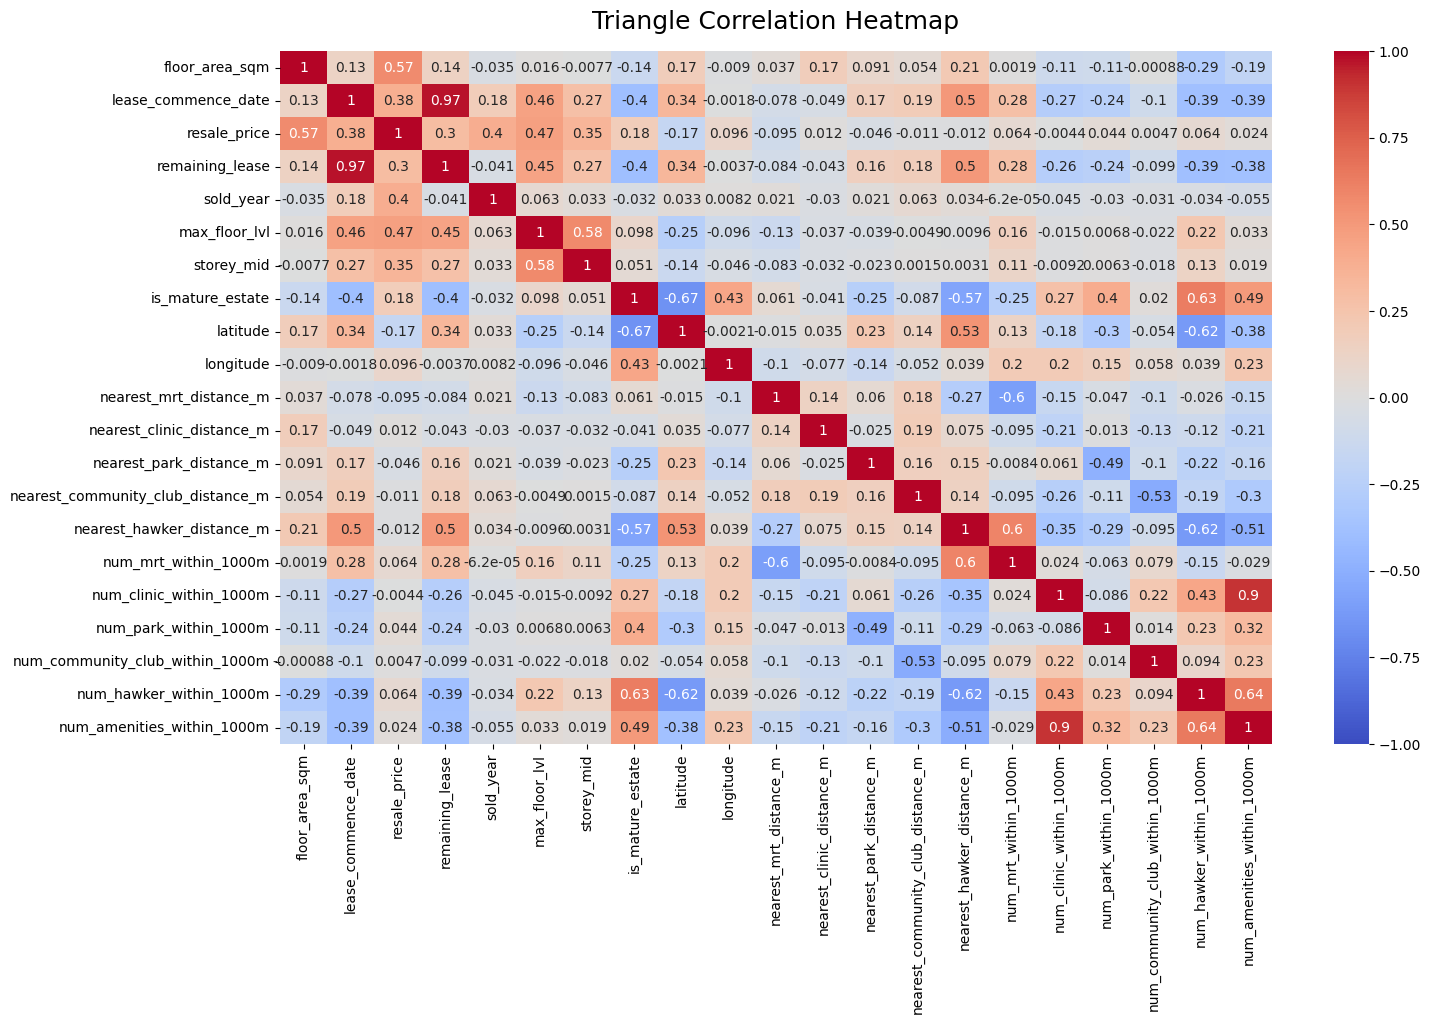

In [8]:
# Calculate the correlation matrix
correlation_matrix = hdb_df.select_dtypes(include=np.number).corr()

# Correlation coefficients
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(correlation_matrix, vmin=-1, vmax=1, annot=True, cmap='coolwarm')
heatmap.set_title('Triangle Correlation Heatmap', fontdict={'fontsize':18}, pad=16);

In [9]:
# Threshold for high correlation
threshold = 0.8

# Create empty list to populate
high_correlation_pairs = []

# Double for loop to get value pairs
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            # Get indexes of columns
            col_pair = (correlation_matrix.columns[i], correlation_matrix.columns[j])
            # Append to empty list
            high_correlation_pairs.append(col_pair)

# Print out the pairs of highly correlated columns
for pair in high_correlation_pairs:
    print(pair)

('remaining_lease', 'lease_commence_date')
('num_amenities_within_1000m', 'num_clinic_within_1000m')


Columns to exclude:
- 'lease_commence_date'
- 'num_clinic_within_1000m'

In [10]:
drop_cols = ['lease_commence_date','num_clinic_within_1000m']

hdb_df = hdb_df.drop(columns=drop_cols)

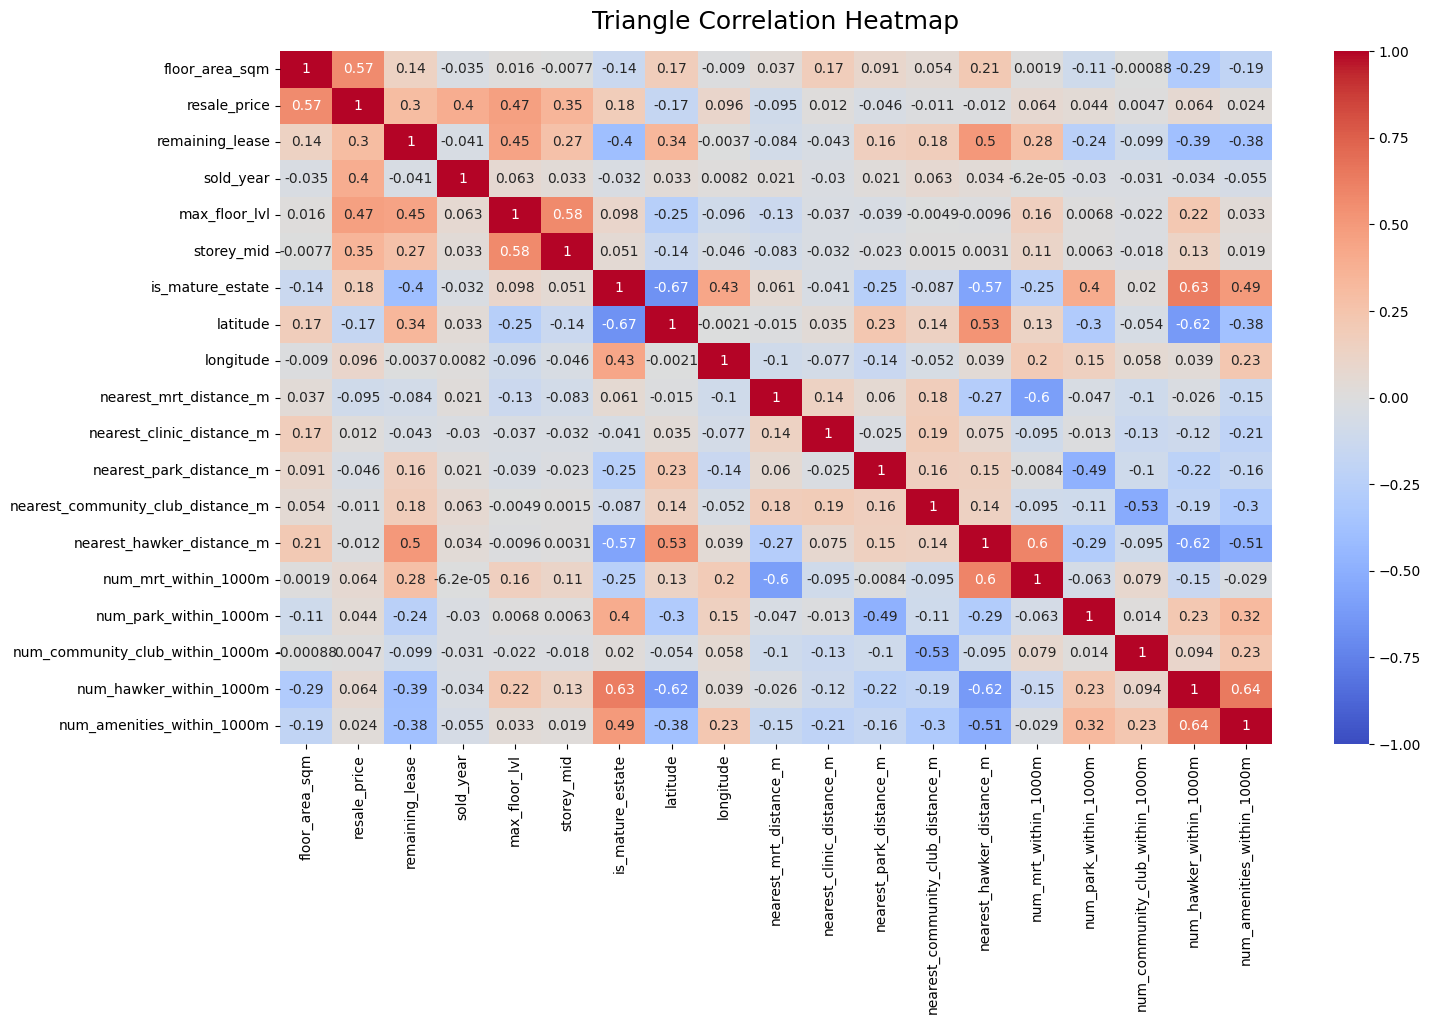

In [11]:
# Calculate the correlation matrix
correlation_matrix = hdb_df.select_dtypes(include=np.number).corr()

# Correlation coefficients
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(correlation_matrix, vmin=-1, vmax=1, annot=True, cmap='coolwarm')
heatmap.set_title('Triangle Correlation Heatmap', fontdict={'fontsize':18}, pad=16);

#### Visualizing Resale Price Against Other Numeric Columns

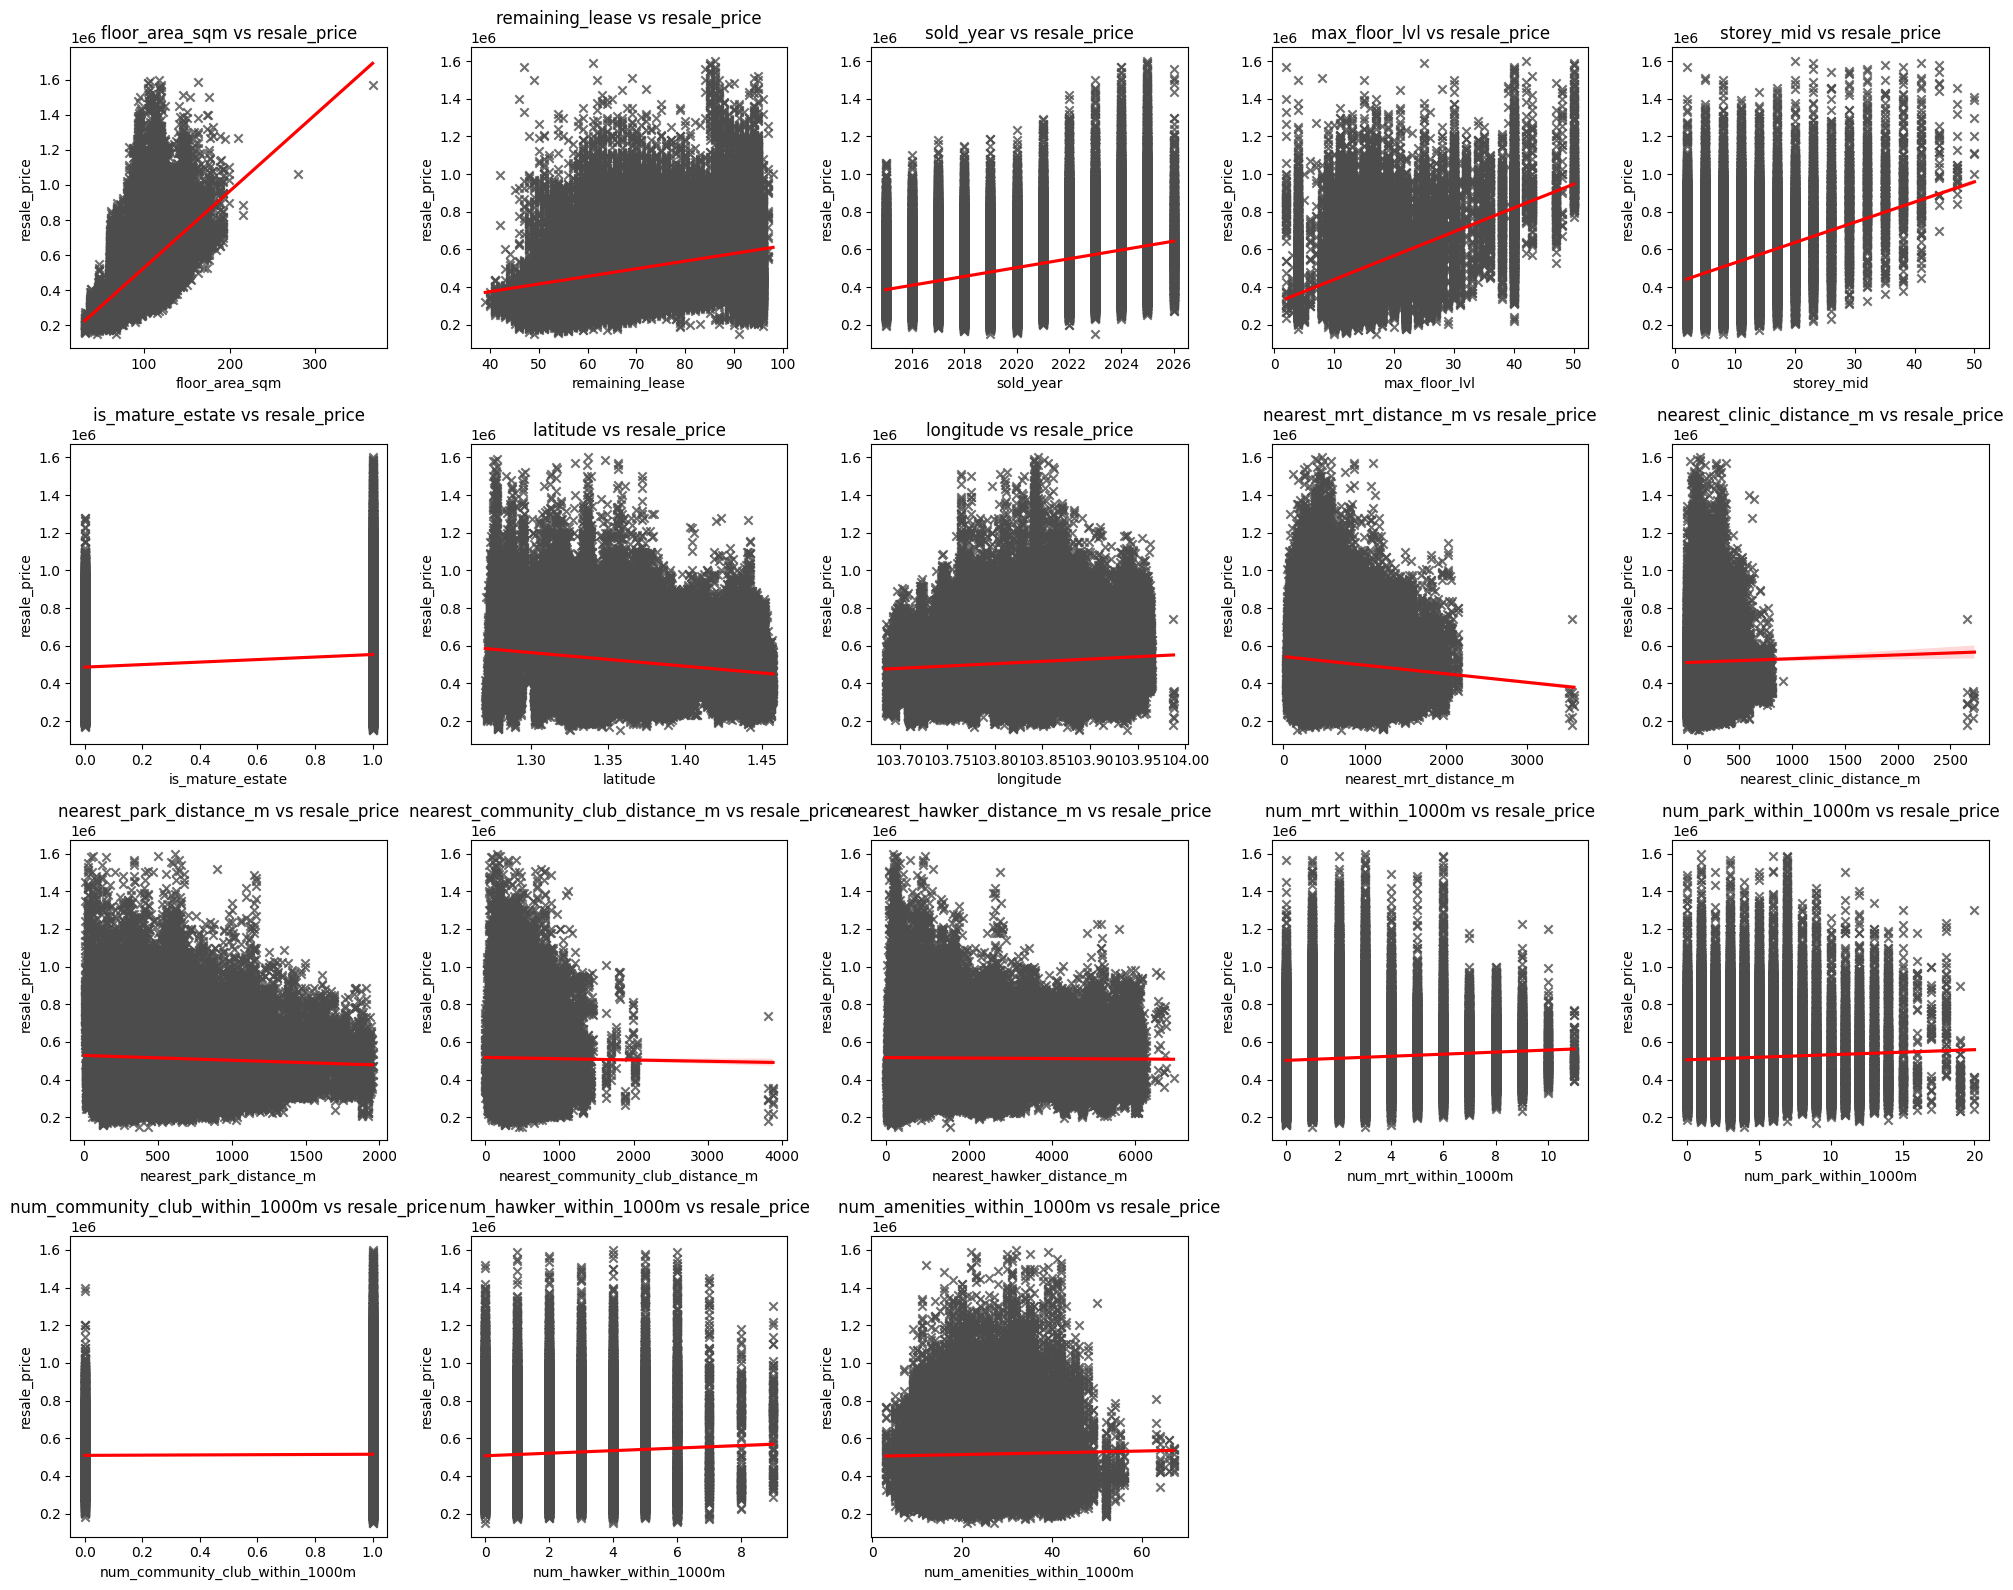

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get a sample of dataset as full DF takes quite a while
temp = hdb_df.sample(100000, random_state=42)

# Get list of numeric columns and select column to plot against
column_of_interest = 'resale_price'
other_columns = temp.select_dtypes(include=['int64', 'float64']).columns.drop(column_of_interest)

# Number of subplot columns
n_cols = 5

# Ceiling division so there are enough subplot rows
n_rows = (len(other_columns) + n_cols - 1) // n_cols

# Create figure with subplots
fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(4 * n_cols, 4 * n_rows))

# Flatten axes array for easy looping
axs = axs.flatten()

# Loop through columns and create regplot
for i, col in enumerate(other_columns):
    sns.regplot(
        data=temp,
        x=col,
        y=column_of_interest,
        ax=axs[i],
        ci=99,
        marker="x",
        color=".3",
        line_kws={"color": "r"}
    )
    axs[i].set_title(f'{col} vs {column_of_interest}')

# Hide unused subplots
for i in range(len(other_columns), len(axs)):
    axs[i].set_visible(False)

# Adjust layout
plt.tight_layout()
plt.show()

In [14]:
# Create lists of the categorical and numerical columns allowing them to be treated differently
cat_cols = hdb_df.select_dtypes(include=['object']).columns

/tmp/ipykernel_11063/2948035398.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = hdb_df.select_dtypes(include=['object']).columns


In [19]:
# Create new list of numeric columns, removing resale_price from columns to scale
num_cols_scale = ['floor_area_sqm',
 'sold_year',
 'remaining_lease',
 'max_floor_lvl']

In [20]:
# Select target column
target_col = 'resale_price'

# Ready X and y
X = hdb_df.loc[:, ~hdb_df.columns.isin([target_col])]
y = hdb_df[target_col]

# Split the data, 80-20 split with a random state included for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 54)


#### Creating a Pipeline 
Pipelines are essentially the backbone of efficient and effective data modeling, ensuring a streamlined, consistent, and flexible approach.

 - Streamlining Processes
   - Pipelines allow the combination of various steps like data preprocessing, feature extraction, and model training into one cohesive process.
 - Consistency and Reproducibility
    - They ensure consistent application of preprocessing and modeling steps for reliable results.
 - Ease of Modification
    - Pipelines allow for easy alterations or replacements of individual components without needing to redo the entire process.
 - Avoiding Data Leakage
     - They prevent data leakage during cross-validation by properly managing data preprocessing steps.
 - Simplifying Code
     - Pipelines contribute to more organized and readable code, making the data modeling process cleaner and more manageable.
 - Model Validation and Parameter Tuning
     - They work well with grid search and cross-validation for effective model optimization and validation.
 - Deployment Ready
     - Pipelines simplify the deployment process as they encapsulate all necessary steps in a model's development.
 - Flexibility
     - They are versatile, accommodating various data transformations and modeling techniques.



#### Preprocessing Pipeline

Feature scaling is important for methods that apply a regularization penalty like Ridge or Lasso regression as we are doing here. 

The penalty applied is sum-of-squares in Ridge and sum-of-absolute values in Lasso. If features are on different scales, the regularization does not treat all features equally. Hence, scaling ensures that the regularization term is applied uniformly across all features.

Also, when features are on the same scale, we can more meaningfully compare the magnitude of coefficients to determine which features have more impact on the outcome.

However, in some cases, you might decide not to scale features - if the scale of the features is relevant to the problem (eg: a feature is bounded between 0 and 100 by definition), scaling may not be necessary and might even be misleading.

In [21]:
# Create instances of OneHotEncoder
cat_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

# Create pipeline of two scalers for numeric data
num_transformer = make_pipeline(RobustScaler(), MinMaxScaler())

# Create a final to apply transformations to subsets of columns
prepoc = make_column_transformer(
    (cat_transformer, cat_cols),
    (num_transformer, num_cols_scale)
)

# View Pipeline
prepoc

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [22]:
# Process X & y with pipeline
X_train_processed = prepoc.fit_transform(X_train)
X_test_processed = prepoc.transform(X_test)

/home/codespace/.local/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [23]:
# See what's in column 6
print("Train unique:", X_train.iloc[:, 6].unique())
print("Test unique:",  X_test.iloc[:, 6].unique())
print("Unknowns:", set(X_test.iloc[:, 6]) - set(X_train.iloc[:, 6]))

Train unique: [2023 2017 2021 2024 2019 2025 2020 2022 2018 2016 2015 2026]
Test unique: [2022 2015 2018 2019 2024 2016 2023 2020 2017 2021 2025 2026]
Unknowns: set()


In [24]:
# Check to see if it worked
print("Number of columns originally:", X.shape[1])
print("Number of columns after preprocessing:",X_train_processed.shape[1])

Number of columns originally: 31
Number of columns after preprocessing: 10850


#### Creating a Base Multivariate Linear Regression Model & Evaluation 

In [27]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Instantiate the model
linear_model = LinearRegression()

# Define multiple scoring metrics (added RMSE + MAPE)
scoring = [
    'r2', 
    'neg_mean_absolute_error',
    'neg_mean_squared_error',           # For RMSE  
    'neg_mean_absolute_percentage_error' # For MAPE
]

# Get the cross validation scores
scores = cross_validate(
    linear_model, 
    X_train_processed, 
    y_train, 
    cv=5, 
    scoring=scoring, 
    return_train_score=False
)

# Calculate and round means
train_r2_mean = round(scores['test_r2'].mean(), 2)
train_mae_mean = round(-(scores['test_neg_mean_absolute_error'].mean()), 2)
train_rmse_mean = round(np.sqrt(-(scores['test_neg_mean_squared_error'].mean())), 2)
train_mape_mean = round(-(scores['test_neg_mean_absolute_percentage_error'].mean()) * 100, 2)

# Print all scores
print("Training R² score =", train_r2_mean)
print("Training MAE =", train_mae_mean) 
print("Training RMSE =", train_rmse_mean)
print("Training MAPE (%) =", train_mape_mean)

# View scores dictionary (unchanged)
scores

Training R² score = 0.91
Training MAE = 42148.64
Training RMSE = 54466.07
Training MAPE (%) = 8.98


{'fit_time': array([14.92826343,  7.39980245,  7.96878886,  7.68699789,  6.76746178]),
 'score_time': array([0.00390506, 0.00383234, 0.00424123, 0.00383234, 0.00562716]),
 'test_r2': array([0.91100987, 0.91258389, 0.9136063 , 0.91150867, 0.91170141]),
 'test_neg_mean_absolute_error': array([-42119.03271356, -42121.60743961, -42107.05582818, -42204.98690013,
        -42190.50164153]),
 'test_neg_mean_squared_error': array([-2.96914000e+09, -2.96855015e+09, -2.95885476e+09, -2.99191871e+09,
        -2.94429993e+09]),
 'test_neg_mean_absolute_percentage_error': array([-0.09001248, -0.0895567 , -0.08965995, -0.0896658 , -0.09003148])}

In [29]:
import numpy as np

# Get rounded scores stored in variables
train_base_r2_mean = round(scores['test_r2'].mean(), 2)
train_base_mae_mean = round(-(scores['test_neg_mean_absolute_error'].mean()), 2)
train_base_rmse_mean = round(np.sqrt(-(scores['test_neg_mean_squared_error'].mean())), 2)
train_base_mape_mean = round(-(scores['test_neg_mean_absolute_percentage_error'].mean()) * 100, 2)

# Print scores to assess
print("Training R² score =", train_base_r2_mean)
print("Training MAE =", train_base_mae_mean)
print("Training RMSE =", train_base_rmse_mean)
print("Training MAPE (%) =", train_base_mape_mean)

Training R² score = 0.91
Training MAE = 42148.64
Training RMSE = 54466.07
Training MAPE (%) = 8.98


**Training R-squared (R²) Score = 0.87:**
 - R-squared is a statistical measure that represents the proportion of the variance for the dependent variable that's explained by the independent variables in a regression model.
 - In general, a higher R² indicates a better fit of the model to the data.
 - An R² score of 0.87 suggests that 87% of the variability in the HDB price can be explained by the model. 
 - An R² score of 0.87 is typically considered high, indicating that the model explains a large proportion of the variance in the outcome variable.
 - However, it's important to note that a high R² does not necessarily mean the model is good. It doesn't indicate whether the model is appropriate, nor does it imply that the predictions are accurate.

**Training Mean Absolute Error (MAE) = 44930.16:**

 - Mean Absolute Error (MAE) gives an average of the absolute errors between the predicted values and the actual values without considering the direction (i.e., over or under-predicting).
 - It's a common measure of forecast error in regression analysis.
 - A MAE of $44930.16 means that, on average, the predictions of the model are off by $44930.16.
 - The magnitude of the MAE needs to be considered in the context of the scale of the dependent variable - HDB prices. For some datasets, an MAE of 44930.16 might be very small, while for others, it might be considered large. Since HDBs cost on average $500K, having a MAE of ~$50K means the model's output for HDB prices is off by 10% on average. 

In [30]:
# Fitting model on data.
linear_model.fit(X_train_processed, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# Predict y with fitted model
y_pred = linear_model.predict(X_test_processed)

# Calculate test set metrics (matching CV metrics)
test_base_mae_mean = round(mean_absolute_error(y_test, y_pred), 2)
test_base_rmse_mean = round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
test_base_r2_mean = round(r2_score(y_test, y_pred), 2)
test_base_mape_mean = round(-(scores['test_neg_mean_absolute_percentage_error'].mean()) * 100, 2)

# Print test scores (matching training format)
print("Testing R² score =", test_base_r2_mean)
print("Testing MAE =", test_base_mae_mean)
print("Testing RMSE =", test_base_rmse_mean)
print("Testing MAPE (%) =", test_base_mape_mean)

Testing R² score = 0.91
Testing MAE = 42186.19
Testing RMSE = 54495.0
Testing MAPE (%) = 8.98


**Testing R-squared (R²) Score = 0.87:**
- An R² of 0.87 for the testing set is also high, suggesting that the model has generalized well to new data. 
- It's particularly notable when the testing R² is close to the training R², as it indicates consistency in performance. 

**Testing Mean Absolute Error (MAE) = 44803.89:**
 - The testing MAE being slightly lower than the training MAE (44803.89 vs. 44930.16) is a positive sign. 
 - It suggests that the model is not overfitting and is performing slightly better or at least as well on unseen data compared to the training data.

**Comments on Scores:**

 Overall, these metrics indicate a model that performs consistently on both training and testing data, with a high R² suggesting good explanatory power and a MAE providing insight into the average prediction error. The similarity between training and testing scores is a good sign, indicating that the model has generalized well and is not just fitting to the peculiarities of the training data.

#### Taking a look at the Feature Coefficients

In [34]:
# To Get importance of features in a DF:
# Get feature names
feature_names = prepoc.get_feature_names_out()

# Get coefficients
coefficients = linear_model.coef_

# Create empty Dictionary
feature_coefficients = {}

# For loop to print coefficient and put them into dict
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef}")
    feature_coefficients[feature] = coef

# Include intercept in the dict
print(f"intercept: {linear_model.intercept_}")
feature_coefficients["intercept"] = linear_model.intercept_

onehotencoder__town_BEDOK: 66239.82116876089
onehotencoder__town_BISHAN: 23081.27010398553
onehotencoder__town_BUKIT BATOK: -33028.48002067243
onehotencoder__town_BUKIT MERAH: -2233.9817968674365
onehotencoder__town_BUKIT PANJANG: -58118.92027456763
onehotencoder__town_BUKIT TIMAH: 55416.61357853023
onehotencoder__town_CENTRAL AREA: 42239.63436545587
onehotencoder__town_CHOA CHU KANG: -83200.6015392062
onehotencoder__town_CLEMENTI: 53583.17129647277
onehotencoder__town_GEYLANG: -33205.16458647885
onehotencoder__town_HOUGANG: -16871.35712572612
onehotencoder__town_JURONG EAST: -7795.776646365626
onehotencoder__town_JURONG WEST: -26372.976414590383
onehotencoder__town_KALLANG/WHAMPOA: -21172.38524465037
onehotencoder__town_MARINE PARADE: 29412.79129843027
onehotencoder__town_PASIR RIS: -48909.362304714356
onehotencoder__town_PUNGGOL: -72167.12939269537
onehotencoder__town_QUEENSTOWN: 44890.331362817036
onehotencoder__town_SEMBAWANG: -36022.12556085368
onehotencoder__town_SENGKANG: -79816

In [36]:
# Converting to DataFrame
feature_coefficients_df = pd.DataFrame(list(feature_coefficients.items()), columns=['Feature', 'Coefficient'])
feature_coefficients_df.head()

,Feature,Coefficient
0,onehotencoder__town_BEDOK,66239.821169
1,onehotencoder__town_BISHAN,23081.270104
2,onehotencoder__town_BUKIT BATOK,-33028.480021
3,onehotencoder__town_BUKIT MERAH,-2233.981797
4,onehotencoder__town_BUKIT PANJANG,-58118.920275


In [37]:
# Sorting the DataFrame by the absolute values of the 'Coefficient' column
feature_coefficients_df = feature_coefficients_df.sort_values(by='Coefficient', key=abs, ascending=False)
feature_coefficients_df.head(15)

,Feature,Coefficient
10846,pipeline__floor_area_sqm,1.128203e+06
61,onehotencoder__flat_model_Terrace,4.161611e+05
10848,pipeline__remaining_lease,2.881670e+05
10847,pipeline__sold_year,2.803532e+05
5549,onehotencoder__matched_address_445A CLEMENTI A...,2.105054e+05
5552,onehotencoder__matched_address_445B CLEMENTI A...,2.096881e+05
1520,onehotencoder__matched_address_160 BISHAN STRE...,1.954870e+05
273,onehotencoder__matched_address_105B BIDADARI P...,1.940722e+05
270,onehotencoder__matched_address_105A BIDADARI P...,1.860244e+05
3250,onehotencoder__matched_address_26B SAINT GEORG...,1.853491e+05


**Comments**

Model seems to make sense, as floor_area_sqm is the single strongest predictor of price, followed by the closest MRT station to the HDB, the year it was sold, and walking times to the closest MRT. 

#### Plots to Evaluate Model Performance ####
##### Residual Plot

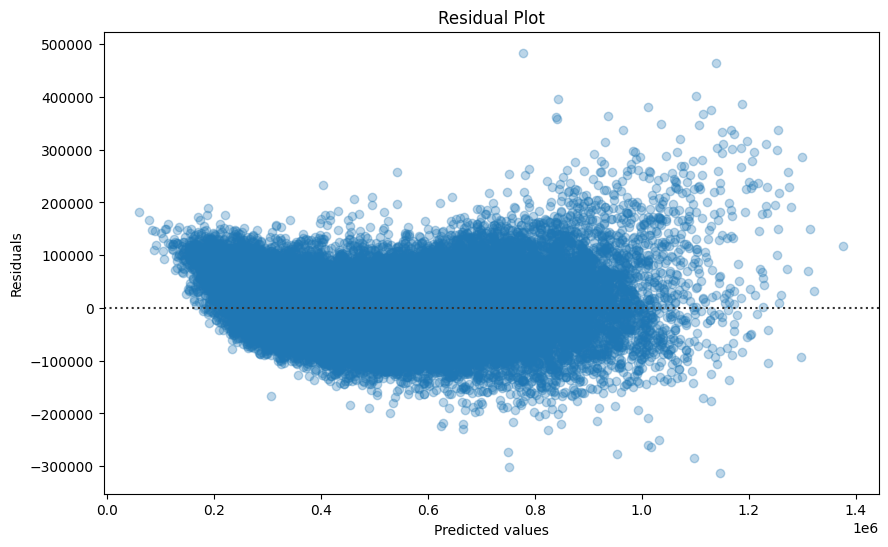

In [38]:
# Get residuals
residuals = y_test - y_pred

# Plot
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, scatter_kws={"alpha": 0.3})
plt.title('Residual Plot')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.show()

**Comments**

- The residuals are spread out and appear to fan out as the predicted values increase. This pattern suggests heteroscedasticity, where the variability of the residuals is not constant across all levels of the independent variable(s). 
- The model's predictions are less precise at higher values of the predictors.
- The density of points is greater near the lower predicted values and lessens as the predicted value increases. This might indicate that the model has more data points or is more accurate at predicting lower values.
- There don't seem to be many individual points that stray very far from the main cloud of points, which suggests that there are not many extreme outliers in the residuals.

**Conclusion**

- A good fit would show the residuals randomly scattered around the horizontal axis (0 line).
- The fanning out of points indicates that the model may benefit from transformations of the dependent variable or the addition of non-linear terms to better capture the variance associated with the data.
- No clear pattern (like a U-shape or an inverted U-shape) is visible, which is good as such patterns could indicate non-linearity in the data that the model isn't capturing.
- Overall, the residual plot suggests that the model may not have a constant variance of errors, which is an assumption of linear regression models. This could be a sign that the model might need to be revised or improved, possibly with a transformation of variables or a different type of model that accounts for the non-constant variance.

##### Histogram of Residuals

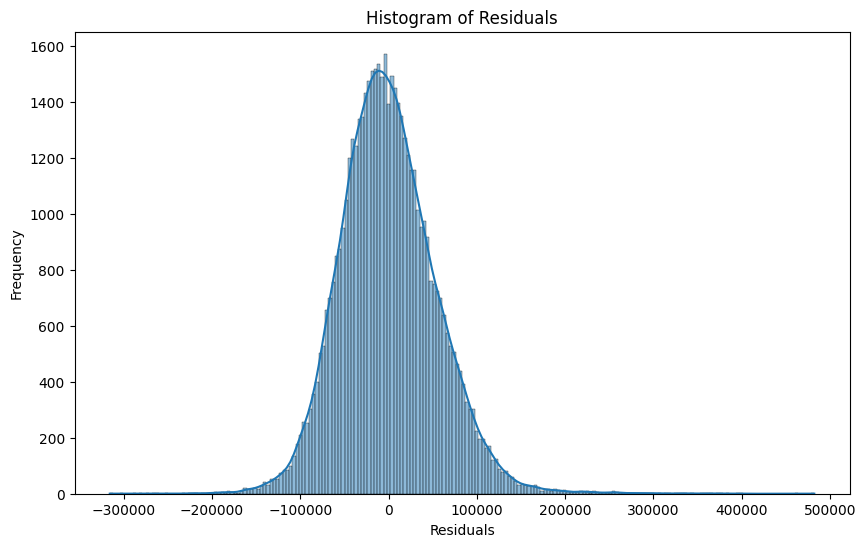

In [39]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

**Comments**

- The histogram bars form a shape that is approximately symmetrical around the center (where the residual is zero). This suggests that the residuals are fairly normally distributed, which is an important assumption in linear regression.
- The curve that fits through the tops of the histogram bars appears to be a normal distribution curve, which suggests that the residuals do not deviate significantly from what would be expected under the assumption of normality.

**Conclusion**

- This plot indicates that the model's assumptions of normally distributed errors might be reasonable.
- A normally distributed residuals histogram is a good sign that the linear regression model is appropriate for the data.
- The symmetry around zero suggests that the model does not have a systematic bias either overestimating or underestimating the dependent variable.
- The tails of the distribution do not show signs of heavy skewness or extreme outliers.

##### Q-Q Plot

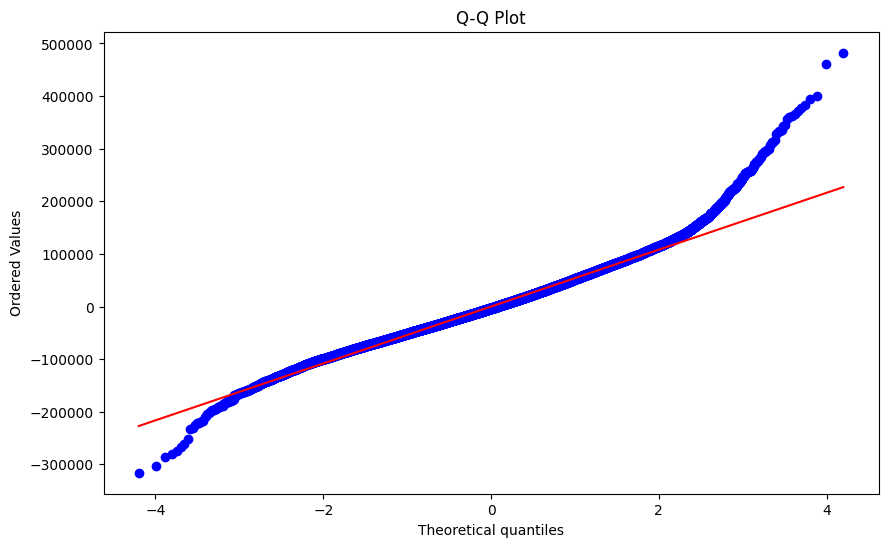

In [40]:
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.show()

**Comments**

- The straight red line represents the place where the points would lie if the data followed a perfect normal distribution.
- Blue dots represent an actual quantile from the dataset plotted against the expected quantile from the normal distribution.
- In the middle portion of the plot (around the 0 of the theoretical quantiles), the points closely follow the reference line, suggesting that the central part of the data is approximately normally distributed.
- The points deviate from the reference line in the tails. In the lower tail (left side of the plot), the data has more extreme values than what would be expected in a normal distribution. The same is true for the upper tail (right side of the plot), where the data points rise above the expected line, indicating heavier tails than a normal distribution.
- The S-shaped curve of the points suggests that the distribution of the dataset has more extreme values compared to a normal distribution. This means that the data may have a higher peak and fatter tails than the normal distribution.

**Conclusion**

- While the central part of the data may resemble a normal distribution, the Q-Q plot indicates that the data exhibit heavier tails, which could impact the assumptions underlying many statistical tests and models that rely on normality. 
- This could be an indication that transformations or alternative modeling techniques might be needed for this dataset.

#### Putting it Together in a Pipeline 

In [43]:
# Read data into csv
file_path = 'HDB_full_resale_info.csv.gz'
df = pd.read_csv(file_path)

# Put all columns to be deleted into a list
drop_cols = ['block', 'street_name','address','sold_year_month']

# Drop columns
df = df.drop(columns=drop_cols, errors='ignore')

num_cols_scale = ['floor_area_sqm',
 'lease_commence_date',
 'sold_year',
 'remaining_lease',
 'max_floor_lvl']

# Instantiate the model
model = LinearRegression()

# Apply transformations to subsets of columns
prepoc = make_column_transformer(
    (cat_transformer, cat_cols),
    (num_transformer, num_cols_scale)
)

#create final pipeline
pipe = make_pipeline(prepoc, model)

pipe


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [44]:
# Select target column
target_col = 'resale_price'

# Ready X and y
X = df.loc[:, ~df.columns.isin([target_col])]
y = df[target_col]

# Split the data, 80-20 split with a random state included for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 54)

# Fit model
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [45]:
# R2 score on training set
r2_baseline_train = pipe.score(X_train, y_train)

# MAE for training
y_pred = pipe.predict(X_train)
mae_baseline_train = mean_absolute_error(y_train, y_pred)

# Print scores to assess
print("Training r2 score =", round(r2_baseline_train, 4))
print("Training MAE score =", round(mae_baseline_train, 2))

Training r2 score = 0.9215
Training MAE score = 39862.19


In [46]:
# R2 score on testing set
r2_baseline_test = pipe.score(X_test, y_test)

# MAE for testing
y_pred = pipe.predict(X_test)
mae_baseline_test = mean_absolute_error(y_test, y_pred)

# Print scores to assess
print("Test r2 score =", round(r2_baseline_test, 4))
print("Test MAE score =", round(mae_baseline_test, 2))

/home/codespace/.local/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Test r2 score = 0.9121
Test MAE score = 42186.0


/home/codespace/.local/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [32]:
#Saving Baseline model
with open('../models/linear_240130.pkl', 'wb') as file:
    pickle.dump(pipe, file)